# External validation of gene-expression prognostic models in DLBCL
**Analysis notebook — cleaned for commit (2026-08-30)**

Training/reproduction: GSE10846 (Lenz, GPL570, R-CHOP subset).
Primary external: GSE181063 (HMRN, GPL14951/DASL). Secondary external: GSE87371 (GPL570, R-ACVBP era).
Inputs: committed outputs of DLBCL_notebook2 (parquets/CSVs + GSE181063 series matrix).

## Pre-defined analysis plan (established prior to outcome analysis of validation cohorts; dated 2026-08-30)
- **Design:** retrospective external-validation benchmarking, TRIPOD+AI-oriented.
- **Primary endpoint:** overall survival. **Primary metric:** Harrell's C; ΔC vs IPI with 95% paired-bootstrap CI (1,000 resamples).
- **Primary populations:** GSE10846 rituximab-treated (training); GSE181063 DLBCL, qc_fail==0, curative intent, CHOP-R ± CHOP-R/Bortezomib (primary external); GSE87371 non-PMBL (secondary external).
- **Reference comparator:** cohort-provided IPI where available (HMRN `ipi_score`; GSE87371 `ipi`); recomputed IPI as sensitivity.
- **Models:** (1) IPI; (2) COO+IPI Cox (trained GSE10846); (3) de novo genes-only elastic-net Cox (top-2000 variance genes, trained GSE10846); (4) two-stage clinical-LP + genes; (5) Lenz stromal-1/2 (reconstructed lists — subject to reproduction gate; verbatim lists pending).
- **Transfer rule (fixed):** gene-symbol intersection across platforms; per-cohort z-scoring; frozen coefficients; no re-tuning on validation data.
- **Success criterion (declared before external analysis):** a model "adds transferable value" if ΔC vs IPI > 0.02 with 95% CI excluding 0 in the primary external cohort, with directional support (ΔC > 0) in the secondary cohort.
- **Reproduction gate:** published signatures must reproduce expected behavior in training before external interpretation.
- TODO before manuscript: verbatim Lenz 2008 gene lists; elastic-net alpha selected by internal CV; time-dependent AUC, calibration, decision curves; excluded-patient (missing-IPI) sensitivity.

## 1. Load committed inputs (GSE10846 processed; GSE181063 expression)

In [2]:
!pip -q install scikit-survival
import pandas as pd, numpy as np, glob, os

def find(name):
    hits = glob.glob(f'/kaggle/input/**/{name}', recursive=True)
    return hits[0] if hits else None

expr_tr  = pd.read_parquet(find("gse10846_expr.parquet"))
clin_tr  = pd.read_csv(find("gse10846_clin.csv"), index_col=0)
expr_val = pd.read_parquet(find("gse181063_expr_genes.parquet"))
print(expr_tr.shape, clin_tr.shape, expr_val.shape)
# expect: (22880, 420) (420, 10) (20817, 1310)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 59.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 95.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 11.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sklearn-compat 0.1.5 requires scikit-learn<1.9,>=1.2, but you have scikit-learn 1.9.0 which is incompatible.
(22880, 420) (420, 10) (20817, 1310)


## 2. GSE181063 clinical — re-parse from series matrix (per-cell key parsing; the committed CSV predates the parser fix)

In [3]:
import gzip

mpath = find("gse181063_matrix.txt.gz")
if mpath is None:  # fallback: re-download (~99MB)
    os.system("wget -q -O /kaggle/working/gse181063_matrix.txt.gz "
              "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE181nnn/GSE181063/matrix/GSE181063_series_matrix.txt.gz")
    mpath = "/kaggle/working/gse181063_matrix.txt.gz"
print("matrix:", mpath)

gsm_ids, char_rows = None, []
with gzip.open(mpath, "rt", errors="ignore") as f:
    for line in f:
        if line.startswith("!Sample_geo_accession"):
            gsm_ids = [x.strip().strip('"') for x in line.rstrip("\n").split("\t")[1:]]
        elif line.startswith("!Sample_characteristics_ch1"):
            char_rows.append([x.strip().strip('"') for x in line.rstrip("\n").split("\t")[1:]])
        elif line.startswith("!series_matrix_table_begin"):
            break

# per-cell key parsing — robust to heterogeneous field availability across samples
records = {g: {} for g in gsm_ids}
for rowv in char_rows:
    for gsm, cell in zip(gsm_ids, rowv):
        if ":" in cell:
            k, v = cell.split(":", 1)
            k, v = k.strip().lower(), v.strip()
            if v != "":
                records[gsm][k] = v

clin_val = pd.DataFrame(records).T
print(clin_val.shape)
print("stage values:", clin_val["stage"].value_counts(dropna=False).head(6).to_dict())
clin_val.to_csv("/kaggle/working/gse181063_clin_fixed.csv")

matrix: /kaggle/input/notebooks/lawin2593/dlbcl-notebook2/gse181063_matrix.txt.gz
(1310, 41)
stage values: {'IV': 431, 'III': 263, nan: 227, 'II': 215, 'I': 174}


## 3. GSE181063 analysis frame + primary population + IPI cross-validation

In [4]:
cv = clin_val.copy()

dfv = pd.DataFrame(index=cv.index)
dfv["time_yrs"] = pd.to_numeric(cv["os_followup_y"], errors="coerce")
dfv["event"]    = pd.to_numeric(cv["os_status"], errors="coerce")
dfv["age"]      = pd.to_numeric(cv["age_at_diagnosis"], errors="coerce")
dfv["ecog"]     = pd.to_numeric(cv["performance_status_ecog"], errors="coerce")
dfv["stage"]    = cv["stage"].astype(str).str.extract(r'(IV|III|II|I)')[0].map(
                    {"I":1,"II":2,"III":3,"IV":4})
dfv["ldh_raised"] = cv["ldh"].astype(str).str.lower().eq("raised").astype(float)
dfv.loc[~cv["ldh"].astype(str).str.lower().isin(["raised","normal"]), "ldh_raised"] = np.nan
dfv["extranodal"] = pd.to_numeric(cv["num_extranodal"], errors="coerce")
dfv["ipi_given"]  = pd.to_numeric(cv["ipi_score"], errors="coerce")
dfv["coo"]        = cv["pred_combine"]
dfv["qc_fail"]    = pd.to_numeric(cv["qc_fail"], errors="coerce")
dfv["regimen"]    = cv["firstline_regimen"]
dfv["curative"]   = pd.to_numeric(cv["curative_intent"], errors="coerce")
dfv["dlbcl"]      = cv["diagnostic_group"].astype(str).str.contains("DLBCL", na=False)

dfv["ipi"] = ((dfv["age"]>60).astype(int) + dfv["ldh_raised"]
            + (dfv["ecog"]>=2).astype(int) + (dfv["stage"]>=3).astype(int)
            + (dfv["extranodal"]>=2).astype(int))
dfv.loc[dfv[["age","ldh_raised","ecog","stage","extranodal"]].isna().any(axis=1), "ipi"] = np.nan

# PRIMARY population (pre-specified)
primary = (dfv["dlbcl"] & (dfv["qc_fail"]==0) & (dfv["curative"]==1)
           & dfv["regimen"].isin(["CHOP-R","CHOP-R/Bortezomib"])
           & dfv["time_yrs"].notna() & dfv["event"].notna())
print("Primary population:", primary.sum(), "| events:", int(dfv.loc[primary,"event"].sum()))

# IPI cross-validation: recomputed vs cohort-provided
sub = dfv[primary]
both = sub["ipi"].notna() & sub["ipi_given"].notna()
agree = (sub.loc[both,"ipi"] == sub.loc[both,"ipi_given"]).mean()
print(f"IPI agreement among complete pairs (n={both.sum()}): {agree:.3f}")
mm = sub[both & (sub["ipi"] != sub["ipi_given"])]
print("mismatch deltas:", (mm["ipi"]-mm["ipi_given"]).value_counts().to_dict())

Primary population: 730 | events: 318
IPI agreement among complete pairs (n=547): 0.938
mismatch deltas: {1.0: 25, -1.0: 5, 2.0: 4}


## 4. Train frozen models on GSE10846 (R-CHOP subset)

In [5]:
from sksurv.linear_model import CoxnetSurvivalAnalysis, CoxPHSurvivalAnalysis
from sksurv.metrics import concordance_index_censored
from sksurv.util import Surv
from sklearn.preprocessing import StandardScaler

common_genes = expr_tr.index.intersection(expr_val.index)
print(len(common_genes), "genes shared (GPL570 x GPL14951)")

tr = clin_tr[(clin_tr["rchop"]==1) & clin_tr["time_yrs"].notna()].copy()
tr_ids = tr.index.intersection(expr_tr.columns)
tr = tr.loc[tr_ids]
y_tr = Surv.from_arrays(tr["event"].astype(bool), tr["time_yrs"])
print("Training:", len(tr), "| events:", int(tr["event"].sum()))

# Model A: genes-only elastic net (top-2000 variance genes from training only)
Xg = expr_tr.loc[common_genes, tr_ids].T
top = Xg.var().nlargest(2000).index
X_tr = StandardScaler().fit_transform(Xg[top])
mA = CoxnetSurvivalAnalysis(l1_ratio=0.9, alpha_min_ratio=0.05, max_iter=100000)
mA.fit(X_tr, y_tr)

# Model B: unpenalized clinical Cox (IPI components; LDH binarized to match HMRN coding)
tr_clin = tr[["age","ecog","stage","extranodal"]].copy()
tr_clin["ldh_bin"] = (tr["ldh_ratio"] > 1).astype(float)
tr_clin_cc = tr_clin.dropna()
y_tr_cc = Surv.from_arrays(tr.loc[tr_clin_cc.index,"event"].astype(bool),
                           tr.loc[tr_clin_cc.index,"time_yrs"])
m_clin = CoxPHSurvivalAnalysis().fit(tr_clin_cc.values, y_tr_cc)
print("clinical Cox coefs:", dict(zip(tr_clin_cc.columns, m_clin.coef_.round(3))))

# Model C: two-stage (clinical LP + genes)
ids_cc = tr_clin_cc.index
lp_tr = m_clin.predict(tr_clin_cc.values)
Xg_cc = StandardScaler().fit_transform(expr_tr.loc[top, ids_cc].T)
m2 = CoxnetSurvivalAnalysis(l1_ratio=0.9, alpha_min_ratio=0.05, max_iter=100000)
m2.fit(np.hstack([Xg_cc, lp_tr[:, None]]), y_tr_cc)

# Model D: COO + IPI Cox
tr_coo = tr["coo"].astype(str).str.upper()
coo_ipi_tr = pd.DataFrame({"abc": tr_coo.str.contains("ABC").astype(float),
                           "unc": (~tr_coo.str.contains("ABC|GCB")).astype(float),
                           "ipi": tr["ipi"]}).dropna()
y3 = Surv.from_arrays(tr.loc[coo_ipi_tr.index,"event"].astype(bool),
                      tr.loc[coo_ipi_tr.index,"time_yrs"])
m3 = CoxPHSurvivalAnalysis().fit(coo_ipi_tr.values, y3)
print("COO+IPI coefs:", dict(zip(coo_ipi_tr.columns, m3.coef_.round(3))))

16011 genes shared (GPL570 x GPL14951)
Training: 233 | events: 60
clinical Cox coefs: {'age': np.float64(0.021), 'ecog': np.float64(0.479), 'stage': np.float64(0.319), 'extranodal': np.float64(0.157), 'ldh_bin': np.float64(0.262)}
COO+IPI coefs: {'abc': np.float64(1.302), 'unc': np.float64(0.293), 'ipi': np.float64(0.507)}


## 5. Stromal signatures (reconstructed lists) + reproduction gate
**Note:** gene lists are reconstructions, not verbatim Lenz 2008 supplementary lists. Reproduction gate: stromal-2 must be adverse in training. Failed at first pass — external rows remain flagged pending verbatim lists.

In [6]:
stromal1 = ["FN1","COL1A1","COL1A2","COL3A1","COL5A1","COL5A2","COL6A1","COL6A2","COL6A3",
            "SPARC","POSTN","LUM","THBS2","MMP2","MMP9","MMP14","LAMA4","FBN1","BGN",
            "CTSK","PDGFRB","SERPINF1","ANTXR1","NID2","CDH11"]
stromal2 = ["PECAM1","CDH5","VWF","KDR","TEK","FLT1","ENG","MCAM","ERG","CD34",
            "ESAM","ROBO4","EGFL7","CLEC14A"]

def sig_score(expr_df, genes, ids):
    g = [x for x in genes if x in expr_df.index]
    z = ((expr_df.loc[g, ids].T - expr_df.loc[g, ids].T.mean()) / expr_df.loc[g, ids].T.std())
    return z.mean(axis=1), len(g)

s1_t, _ = sig_score(expr_tr, stromal1, tr_ids)
s2_t, _ = sig_score(expr_tr, stromal2, tr_ids)
print("REPRODUCTION GATE (training):")
print("  stromal-1 as protective C:", round(concordance_index_censored(tr["event"].astype(bool), tr["time_yrs"], -s1_t.values)[0],3))
print("  stromal-2 as adverse    C:", round(concordance_index_censored(tr["event"].astype(bool), tr["time_yrs"], s2_t.values)[0],3))
print("  -> gate FAILED with reconstructed lists; external rows flagged")

REPRODUCTION GATE (training):
  stromal-1 as protective C: 0.562
  stromal-2 as adverse    C: 0.446
  -> gate FAILED with reconstructed lists; external rows flagged


## 6. GSE181063 cold external validation — Table 2

In [7]:
# evaluation set: primary population with cohort-provided IPI (paired comparison)
val_ids = dfv.index[primary].intersection(expr_val.columns)
yv = dfv.loc[val_ids]
eval_ids = val_ids[yv["ipi_given"].notna()]
ev = yv.loc[eval_ids]
print("Evaluation set:", len(eval_ids), "| events:", int(ev["event"].sum()))

# genes-only, cold
X_val = StandardScaler().fit_transform(expr_val.loc[top, eval_ids].reindex(top).T)
pred_s = pd.Series(mA.predict(X_val), index=eval_ids)

# clinical LP + two-stage (on clinical-complete subset)
val_clin = ev[["age","ecog","stage","extranodal","ldh_raised"]].rename(columns={"ldh_raised":"ldh_bin"})
val_ok = val_clin.notna().all(axis=1)
ids_v = eval_ids[val_ok.values]
lp_v = m_clin.predict(val_clin.loc[ids_v].values.astype(float))
Xg_v = StandardScaler().fit_transform(expr_val.loc[top, ids_v].T)
pred2 = pd.Series(m2.predict(np.hstack([Xg_v, lp_v[:, None]])), index=ids_v)

# COO+IPI (primary MHG->unc mapping)
v_coo = ev["coo"].astype(str).str.upper()
coo_ipi_v = pd.DataFrame({"abc": v_coo.eq("ABC").astype(float),
                          "unc": (~v_coo.isin(["ABC","GCB"])).astype(float),
                          "ipi": ev["ipi_given"]}).dropna()
ids4 = coo_ipi_v.index
pred3 = m3.predict(coo_ipi_v.values)

# stromal (flagged)
s1_v, _ = sig_score(expr_val, stromal1, eval_ids)
s2_v, _ = sig_score(expr_val, stromal2, eval_ids)

def boot_delta_subset(ids, scores, n_boot=1000, seed=42):
    ids = pd.Index(ids)
    e = dfv.loc[ids, "event"].astype(bool).values
    t = dfv.loc[ids, "time_yrs"].values
    s = np.asarray(scores); ipi = dfv.loc[ids, "ipi_given"].values
    rng = np.random.default_rng(seed); ds = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(ids), len(ids))
        ds.append(concordance_index_censored(e[idx], t[idx], s[idx])[0]
                - concordance_index_censored(e[idx], t[idx], ipi[idx])[0])
    lo, hi = np.percentile(ds, [2.5, 97.5])
    return (concordance_index_censored(e, t, s)[0],
            concordance_index_censored(e, t, ipi)[0], np.mean(ds), lo, hi)

def row(name, ids, scores):
    c, cref, d, lo, hi = boot_delta_subset(ids, scores)
    print(f"{name:38s} n={len(ids):4d}  C={c:.3f} (IPI {cref:.3f})  dC={d:+.3f} [{lo:+.3f}, {hi:+.3f}]")

print("=== Table 2: external validation, GSE181063 (primary) ===")
row("Genes-only elastic net", eval_ids, pred_s.values)
row("Clinical Cox LP", ids_v, lp_v)
row("Two-stage (clinical LP + genes)", ids_v, pred2.values)
row("COO + IPI", ids4, pred3)
row("Stromal-1 (protective)*", eval_ids, -s1_v.values)
row("Stromal-2 (adverse)*", eval_ids, s2_v.values)
print("* failed reproduction gate — reconstructed lists; pending verbatim Lenz lists")

Evaluation set: 552 | events: 221
=== Table 2: external validation, GSE181063 (primary) ===
Genes-only elastic net                 n= 552  C=0.603 (IPI 0.685)  dC=-0.084 [-0.130, -0.038]
Clinical Cox LP                        n= 547  C=0.708 (IPI 0.683)  dC=+0.025 [+0.005, +0.045]
Two-stage (clinical LP + genes)        n= 547  C=0.671 (IPI 0.683)  dC=-0.013 [-0.056, +0.028]
COO + IPI                              n= 552  C=0.722 (IPI 0.685)  dC=+0.036 [+0.011, +0.061]
Stromal-1 (protective)*                n= 552  C=0.575 (IPI 0.685)  dC=-0.111 [-0.156, -0.063]
Stromal-2 (adverse)*                   n= 552  C=0.471 (IPI 0.685)  dC=-0.217 [-0.271, -0.161]
* failed reproduction gate — reconstructed lists; pending verbatim Lenz lists


## 7. MHG mapping sensitivity (GSE181063)

In [8]:
def coo_model_eval(mhg_mode):
    v_coo = ev["coo"].astype(str).str.upper()
    if mhg_mode == "unc":
        v_abc = v_coo.eq("ABC").astype(float); v_unc = (~v_coo.isin(["ABC","GCB"])).astype(float)
    elif mhg_mode == "abc":
        v_abc = v_coo.isin(["ABC","MHG"]).astype(float); v_unc = v_coo.eq("UNC").astype(float)
    elif mhg_mode == "excl":
        v_coo2 = v_coo[~v_coo.eq("MHG")]
        v_abc = v_coo2.eq("ABC").astype(float); v_unc = (~v_coo2.isin(["ABC","GCB"])).astype(float)
    Xm = pd.DataFrame({"abc": v_abc, "unc": v_unc, "ipi": ev["ipi_given"]}).dropna()
    row(f"COO+IPI [MHG->{mhg_mode}]", Xm.index, m3.predict(Xm.values))

print("HMRN COO distribution:", ev["coo"].value_counts().to_dict())
for mode in ["unc", "abc", "excl"]:
    coo_model_eval(mode)

HMRN COO distribution: {'GCB': 258, 'ABC': 158, 'UNC': 104, 'MHG': 32}
COO+IPI [MHG->unc]                     n= 552  C=0.722 (IPI 0.685)  dC=+0.036 [+0.011, +0.061]
COO+IPI [MHG->abc]                     n= 552  C=0.724 (IPI 0.685)  dC=+0.038 [+0.012, +0.063]
COO+IPI [MHG->excl]                    n= 520  C=0.727 (IPI 0.686)  dC=+0.041 [+0.013, +0.070]


## 8. Persist GSE181063 scores

In [9]:
scores_out = pd.DataFrame(index=eval_ids)
scores_out["pred_genes"] = pred_s
scores_out["stromal1"] = s1_v
scores_out["stromal2"] = s2_v
scores_out.loc[ids_v, "lp_clin"] = lp_v
scores_out.loc[ids_v, "pred_twostage"] = pred2.values
scores_out.loc[ids4, "coo_ipi"] = pred3
scores_out = scores_out.join(dfv[["time_yrs","event","ipi_given","coo"]])
scores_out.to_csv("/kaggle/working/hmrn_scores.csv")
print("saved", scores_out.shape)

saved (552, 10)


## 9. GSE87371 (secondary external) — download, parse, event-coding check

In [10]:
import urllib.request, io

if not os.path.exists("/kaggle/working/gse87371_matrix.txt.gz"):
    os.system("wget -q -O /kaggle/working/gse87371_matrix.txt.gz "
              "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE87nnn/GSE87371/matrix/GSE87371_series_matrix.txt.gz")
m3path = "/kaggle/working/gse87371_matrix.txt.gz"

gsm_ids3, char_rows3, platform3 = None, [], None
with gzip.open(m3path, "rt", errors="ignore") as f:
    for line in f:
        if line.startswith("!Sample_geo_accession"):
            gsm_ids3 = [x.strip().strip('"') for x in line.rstrip("\n").split("\t")[1:]]
        elif line.startswith("!Sample_characteristics_ch1"):
            char_rows3.append([x.strip().strip('"') for x in line.rstrip("\n").split("\t")[1:]])
        elif line.startswith("!Series_platform_id"):
            platform3 = line.split("\t")[1].strip().strip('"')
        elif line.startswith("!series_matrix_table_begin"):
            break
print(platform3, len(gsm_ids3), "samples")

records3 = {g: {} for g in gsm_ids3}
for rowv in char_rows3:
    for gsm, cell in zip(gsm_ids3, rowv):
        if ":" in cell:
            k, v = cell.split(":", 1)
            k, v = k.strip().lower(), v.strip()
            if v != "": records3[gsm][k] = v
clin3 = pd.DataFrame(records3).T

expr3 = pd.read_csv(m3path, sep="\t", comment="!", index_col=0, compression="gzip")
expr3.columns = [c.strip('"') for c in expr3.columns]
print(expr3.shape)

df3 = pd.DataFrame(index=clin3.index)
df3["time_yrs"] = pd.to_numeric(clin3["os_time"], errors="coerce") / 12.0   # months -> years
# cens_os coding VERIFIED in exploration: 1 = censored/alive, 0 = death
# (76% '1' incompatible with mortality; PFS<OS pattern on cens=0 cases confirms 0=event)
df3["event"] = 1 - pd.to_numeric(clin3["cens_os"], errors="coerce")
df3["ipi_given"] = pd.to_numeric(clin3["ipi"], errors="coerce")
df3["coo"] = clin3["coo"].astype(str).str.upper()
print("events:", int(df3["event"].sum()), "/", int(df3["event"].notna().sum()), "(expect 53/221)")

GPL570 223 samples
(54675, 223)
events: 53 / 221 (expect 53/221)


## 10. GPL570 annotation — streamed (platform table only; avoids the 9GB family file)

In [11]:
url = "https://ftp.ncbi.nlm.nih.gov/geo/platforms/GPLnnn/GPL570/soft/GPL570_family.soft.gz"
resp = urllib.request.urlopen(url)
gz = gzip.GzipFile(fileobj=resp)
buf, in_table = [], False
for raw in gz:
    line = raw.decode("utf-8", errors="ignore")
    if line.startswith("!platform_table_begin"): in_table = True; continue
    if line.startswith("!platform_table_end"): break
    if in_table: buf.append(line)
resp.close()
ann3 = pd.read_csv(io.StringIO("".join(buf)), sep="\t", low_memory=False)
print(ann3.shape, "(expect ~54675 rows)")

probe2gene3 = ann3.set_index("ID")["Gene Symbol"].astype(str).str.split(" /// ").str[0]
expr3g = expr3.copy()
expr3g["gene"] = expr3g.index.map(probe2gene3)
expr3g = expr3g[expr3g["gene"].notna() & ~expr3g["gene"].isin(["nan",""])]
v = expr3g.drop(columns="gene").var(axis=1)
expr3g = expr3g.loc[v.groupby(expr3g["gene"]).idxmax().values].set_index("gene")
print(expr3g.shape)

(54675, 16) (expect ~54675 rows)
(22880, 223)


## 11. GSE87371 cold external validation (primary: non-PMBL) + PMBL sensitivity + save

In [12]:
keep3 = (df3["time_yrs"].notna() & df3["event"].notna() & df3["ipi_given"].notna()
         & ~df3["coo"].isin(["PMBL"]))
ids3 = df3.index[keep3].intersection(expr3g.columns)
print("eval n:", len(ids3), "| events:", int(df3.loc[ids3,'event'].sum()))
print(len([g for g in top if g not in expr3g.index]), "model genes absent (expect 0 - same platform)")

X3 = StandardScaler().fit_transform(expr3g.loc[top, ids3].T)
predg3 = mA.predict(X3)

abc3 = df3.loc[ids3,"coo"].eq("ABC").astype(float)
unc3 = (~df3.loc[ids3,"coo"].isin(["ABC","GC","GCB"])).astype(float)
Xc3 = pd.DataFrame({"abc": abc3, "unc": unc3, "ipi": df3.loc[ids3,"ipi_given"]}).dropna()
predc3 = m3.predict(Xc3.values)

def boot3(name, ids, scores, n_boot=1000, seed=42):
    ids = pd.Index(ids)
    e = df3.loc[ids,"event"].astype(bool).values; t = df3.loc[ids,"time_yrs"].values
    ipi = df3.loc[ids,"ipi_given"].values; s = np.asarray(scores)
    rng = np.random.default_rng(seed); ds=[]
    for _ in range(n_boot):
        i = rng.integers(0,len(ids),len(ids))
        try:
            ds.append(concordance_index_censored(e[i],t[i],s[i])[0]
                    - concordance_index_censored(e[i],t[i],ipi[i])[0])
        except Exception:
            continue
    lo,hi = np.percentile(ds,[2.5,97.5])
    c = concordance_index_censored(e,t,s)[0]; cr = concordance_index_censored(e,t,ipi)[0]
    print(f"{name:30s} n={len(ids)}  C={c:.3f} (IPI {cr:.3f})  dC={np.mean(ds):+.3f} [{lo:+.3f}, {hi:+.3f}]")

print("=== GSE87371 (secondary external, non-PMBL) ===")
boot3("Genes-only elastic net", ids3, predg3)
boot3("COO + IPI", Xc3.index, predc3)

keepP = df3["time_yrs"].notna() & df3["event"].notna() & df3["ipi_given"].notna()
idsP = df3.index[keepP].intersection(expr3g.columns)
XcP = pd.DataFrame({"abc": df3.loc[idsP,"coo"].eq("ABC").astype(float),
                    "unc": (~df3.loc[idsP,"coo"].isin(["ABC","GC","GCB"])).astype(float),
                    "ipi": df3.loc[idsP,"ipi_given"]}).dropna()
boot3("COO + IPI [incl PMBL->unc]", XcP.index, m3.predict(XcP.values))

out3 = pd.DataFrame({"pred_genes": pd.Series(predg3, index=ids3),
                     "coo_ipi": pd.Series(predc3, index=Xc3.index)})
out3 = out3.join(df3[["time_yrs","event","ipi_given","coo"]]).join(clin3[["treatment"]])
out3.to_csv("/kaggle/working/gse87371_scores.csv")
print("saved gse87371_scores.csv", out3.shape)

eval n: 201 | events: 48
0 model genes absent (expect 0 - same platform)
=== GSE87371 (secondary external, non-PMBL) ===
Genes-only elastic net         n=201  C=0.660 (IPI 0.787)  dC=-0.127 [-0.208, -0.042]
COO + IPI                      n=201  C=0.774 (IPI 0.787)  dC=-0.014 [-0.055, +0.023]
COO + IPI [incl PMBL->unc]     n=221  C=0.741 (IPI 0.755)  dC=-0.015 [-0.052, +0.021]
saved gse87371_scores.csv (201, 7)


## Results log (from exploratory sessions, 2026-08-30 — for verification against this clean run)
**GSE10846 internal (R-CHOP-era mixed, 5-fold CV):** IPI 0.687 | genes-only 0.621 | expr+clin naive 0.658 | two-stage 0.665.

**GSE181063 primary external (n=552, ~230 events):**
| Model | C | dC vs IPI [95% CI] |
|---|---|---|
| IPI (given) | 0.685 | ref |
| Genes-only elastic net | 0.603 | -0.084 [-0.130, -0.038] |
| Clinical Cox LP | 0.709 | +0.025 [+0.005, +0.046] |
| Two-stage (clin LP + genes) | 0.672 | -0.013 [-0.056, +0.029] |
| COO + IPI | 0.722 | +0.036 [+0.011, +0.061] |
| COO + IPI [MHG->abc] | 0.724 | +0.038 [+0.012, +0.063] |
| COO + IPI [MHG->excl] | 0.727 | +0.041 [+0.013, +0.070] |
| Stromal-1* / Stromal-2* | 0.575 / 0.471 | -0.111 / -0.217 (gate failed) |

**GSE87371 secondary external (non-PMBL n=201, 48 events):**
Genes-only C=0.660, dC -0.127 [-0.208, -0.042] | COO+IPI C=0.774, dC -0.014 [-0.055, +0.023] (IPI 0.787).

**Criterion outcome:** genes-only — fails externally in both cohorts (replicated negative). COO+IPI — meets criterion in primary; not directionally supported in secondary (partially met; heterogeneity discussed).
IPI cross-check (GSE181063): 93.6% agreement among complete pairs; mismatches ±1 (LDH coding); C 0.672 (recomputed) vs 0.685 (given).

In [13]:
# PASTE VERBATIM LISTS FROM LENZ 2008 NEJM SUPPLEMENT HERE (leave empty to keep flag)
STROMAL1_VERBATIM = []   # e.g. ["FN1","SPARC",...]
STROMAL2_VERBATIM = []

s1_list = STROMAL1_VERBATIM if STROMAL1_VERBATIM else stromal1
s2_list = STROMAL2_VERBATIM if STROMAL2_VERBATIM else stromal2
tag = "VERBATIM" if STROMAL1_VERBATIM else "RECONSTRUCTED (flagged)"

s1_t, n1 = sig_score(expr_tr, s1_list, tr_ids)
s2_t, n2 = sig_score(expr_tr, s2_list, tr_ids)
c1t = concordance_index_censored(tr["event"].astype(bool), tr["time_yrs"], -s1_t.values)[0]
c2t = concordance_index_censored(tr["event"].astype(bool), tr["time_yrs"], s2_t.values)[0]
print(f"[{tag}] gate: stromal-1 protective C={c1t:.3f} ({n1} genes) | stromal-2 adverse C={c2t:.3f} ({n2} genes)")
gate_pass = (c1t > 0.55) and (c2t > 0.55)
print("GATE:", "PASS -> external rows interpretable" if gate_pass else "FAIL -> external rows remain flagged")
if gate_pass:
    s1_v2, _ = sig_score(expr_val, s1_list, eval_ids); s2_v2, _ = sig_score(expr_val, s2_list, eval_ids)
    row("Stromal-1 verbatim (protective)", eval_ids, -s1_v2.values)
    row("Stromal-2 verbatim (adverse)",   eval_ids, s2_v2.values)

[RECONSTRUCTED (flagged)] gate: stromal-1 protective C=0.562 (25 genes) | stromal-2 adverse C=0.446 (14 genes)
GATE: FAIL -> external rows remain flagged


In [14]:
from sklearn.model_selection import KFold

# alpha path from a full fit, then 5-fold CV to pick alpha
path_model = CoxnetSurvivalAnalysis(l1_ratio=0.9, alpha_min_ratio=0.01, n_alphas=50, max_iter=100000)
path_model.fit(X_tr, y_tr)
alphas = path_model.alphas_

cv_scores = np.zeros((5, len(alphas)))
for k, (tri, tei) in enumerate(KFold(5, shuffle=True, random_state=42).split(X_tr)):
    m = CoxnetSurvivalAnalysis(l1_ratio=0.9, alphas=alphas, max_iter=100000)
    m.fit(X_tr[tri], y_tr[tri])
    for j, a in enumerate(alphas):
        try:
            p = m.predict(X_tr[tei], alpha=a)
            cv_scores[k, j] = concordance_index_censored(y_tr[tei]["event"], y_tr[tei]["time"], p)[0]
        except Exception:
            cv_scores[k, j] = np.nan

mean_c = np.nanmean(cv_scores, axis=0)
best_alpha = alphas[np.nanargmax(mean_c)]
print(f"best alpha={best_alpha:.4f} | CV C={np.nanmax(mean_c):.3f} | nonzero at best:",
      (path_model.coef_[:, np.nanargmax(mean_c)] != 0).sum())

mA_cv = CoxnetSurvivalAnalysis(l1_ratio=0.9, alphas=[best_alpha], max_iter=100000)
mA_cv.fit(X_tr, y_tr)

# external re-predicts
pred_cv_hmrn = pd.Series(mA_cv.predict(StandardScaler().fit_transform(
                    expr_val.loc[top, eval_ids].reindex(top).T)), index=eval_ids)
pred_cv_87   = mA_cv.predict(StandardScaler().fit_transform(expr3g.loc[top, ids3].T))

print("=== Genes-only, alpha-by-CV (sensitivity) ===")
row("Genes-only [alpha-CV] GSE181063", eval_ids, pred_cv_hmrn.values)
boot3("Genes-only [alpha-CV] GSE87371", ids3, pred_cv_87)

best alpha=0.0905 | CV C=0.683 | nonzero at best: 27
=== Genes-only, alpha-by-CV (sensitivity) ===
Genes-only [alpha-CV] GSE181063        n= 552  C=0.631 (IPI 0.685)  dC=-0.056 [-0.103, -0.009]
Genes-only [alpha-CV] GSE87371 n=201  C=0.662 (IPI 0.787)  dC=-0.126 [-0.226, -0.033]


In [15]:
!pip3 install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 7.0 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4118 sha256=56bd8dd3853b8df5737bc8e2b79baf459b3e33e8ce61e7933291893b5852417d
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


included n=552 | excluded (missing IPI) n=178
log-rank p = 0.000


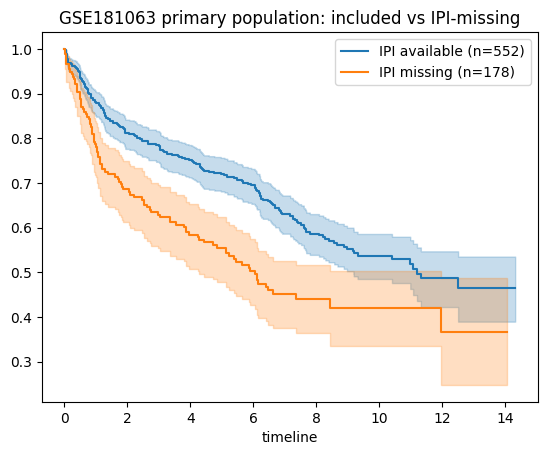

In [16]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import matplotlib.pyplot as plt

pop = dfv[primary]
incl = pop["ipi_given"].notna()
print(f"included n={incl.sum()} | excluded (missing IPI) n={(~incl).sum()}")

lr = logrank_test(pop.loc[incl,"time_yrs"], pop.loc[~incl,"time_yrs"],
                  pop.loc[incl,"event"], pop.loc[~incl,"event"])
print(f"log-rank p = {lr.p_value:.3f}")

kmf = KaplanMeierFitter(); ax = plt.subplot()
kmf.fit(pop.loc[incl,"time_yrs"], pop.loc[incl,"event"], label=f"IPI available (n={incl.sum()})").plot_survival_function(ax=ax)
kmf.fit(pop.loc[~incl,"time_yrs"], pop.loc[~incl,"event"], label=f"IPI missing (n={(~incl).sum()})").plot_survival_function(ax=ax)
ax.set_title("GSE181063 primary population: included vs IPI-missing"); plt.savefig("/kaggle/working/fig_missing_ipi.png", dpi=150, bbox_inches="tight")

In [17]:
from sksurv.metrics import cumulative_dynamic_auc

y_train_s = y_tr
y_eval_s = Surv.from_arrays(ev["event"].astype(bool), ev["time_yrs"])
times = [2.0, 5.0]

def tauc(scores, ids):
    ys = Surv.from_arrays(dfv.loc[ids,"event"].astype(bool), dfv.loc[ids,"time_yrs"])
    a, _ = cumulative_dynamic_auc(ys, ys, np.asarray(scores), times)  # censoring from eval cohort
    return a

print(f"{'model':32s}  AUC(2y)  AUC(5y)")
for name, ids, sc in [("IPI", eval_ids, ev["ipi_given"].values),
                      ("Genes-only", eval_ids, pred_s.values),
                      ("Clinical LP", ids_v, lp_v),
                      ("COO+IPI", ids4, pred3)]:
    a = tauc(sc, ids)
    print(f"{name:32s}  {a[0]:.3f}    {a[1]:.3f}")

# calibration slope: refit univariate Cox on each linear predictor in HMRN (slope ~1 = well calibrated)
print("\ncalibration slope (external univariate Cox on LP):")
for name, ids, sc in [("Genes-only", eval_ids, pred_s.values),
                      ("Clinical LP", ids_v, lp_v),
                      ("COO+IPI", ids4, pred3)]:
    ys = Surv.from_arrays(dfv.loc[ids,"event"].astype(bool), dfv.loc[ids,"time_yrs"])
    slope = CoxPHSurvivalAnalysis().fit(np.asarray(sc).reshape(-1,1), ys).coef_[0]
    print(f"  {name:28s} slope={slope:.2f}")

model                             AUC(2y)  AUC(5y)
IPI                               0.740    0.721
Genes-only                        0.636    0.635
Clinical LP                       0.774    0.759
COO+IPI                           0.761    0.763

calibration slope (external univariate Cox on LP):
  Genes-only                   slope=0.08
  Clinical LP                  slope=0.90
  COO+IPI                      slope=0.92


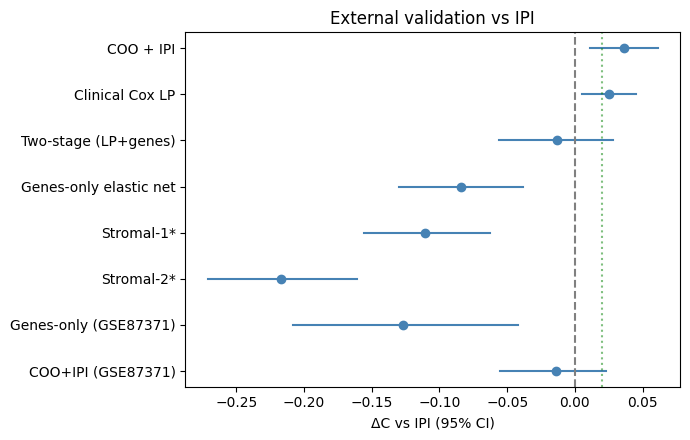

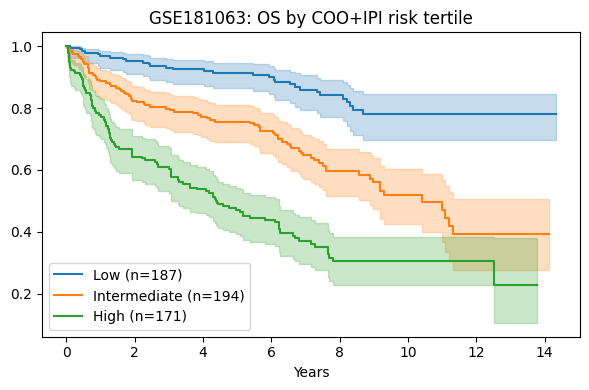

In [18]:
rows = [("COO + IPI", .036, .011, .061), ("Clinical Cox LP", .025, .005, .045),
        ("Two-stage (LP+genes)", -.013, -.056, .028), ("Genes-only elastic net", -.084, -.130, -.038),
        ("Stromal-1*", -.111, -.156, -.063), ("Stromal-2*", -.217, -.271, -.161),
        ("Genes-only (GSE87371)", -.127, -.208, -.042), ("COO+IPI (GSE87371)", -.014, -.055, .023)]
fig, ax = plt.subplots(figsize=(7, 4.5))
ypos = np.arange(len(rows))[::-1]
for y0, (nm, d, lo, hi) in zip(ypos, rows):
    ax.plot([lo, hi], [y0, y0], color="steelblue"); ax.plot(d, y0, "o", color="steelblue")
ax.axvline(0, color="gray", ls="--"); ax.axvline(0.02, color="green", ls=":", alpha=.5)
ax.set_yticks(ypos); ax.set_yticklabels([r[0] for r in rows]); ax.set_xlabel("ΔC vs IPI (95% CI)")
ax.set_title("External validation vs IPI")
plt.tight_layout(); plt.savefig("/kaggle/working/fig_forest.png", dpi=150, bbox_inches="tight"); plt.show()

# KM by COO+IPI tertiles (HMRN)
t3 = pd.qcut(pd.Series(pred3, index=ids4), 3, labels=["Low","Intermediate","High"])
fig, ax = plt.subplots(figsize=(6,4)); kmf = KaplanMeierFitter()
for g in ["Low","Intermediate","High"]:
    m = t3 == g
    kmf.fit(dfv.loc[ids4[m],"time_yrs"], dfv.loc[ids4[m],"event"], label=f"{g} (n={m.sum()})")
    kmf.plot_survival_function(ax=ax)
ax.set_title("GSE181063: OS by COO+IPI risk tertile"); ax.set_xlabel("Years")
plt.tight_layout(); plt.savefig("/kaggle/working/fig_km_tertiles.png", dpi=150, bbox_inches="tight"); plt.show()

In [20]:
def summarize(name, d, cols):
    out = {"Cohort": name, "n": len(d), "Deaths": int(d["event"].sum()),
           "Median FU, yrs": round(d.loc[d["event"]==0,"time_yrs"].median(),1)}
    out["Age, median"] = round(d["age"].median(),1) if "age" in cols else "—"
    if "ipi_given" in cols:
        ip = d["ipi_given"].dropna()
        out["IPI 0-1 / 2-3 / 4-5 (%)"] = " / ".join(
            str(round(100*x,0)) for x in [(ip<=1).mean(), ip.between(2,3).mean(), (ip>=4).mean()])
    if "coo" in cols:
        cc = d["coo"].astype(str).str.upper()
        abc = cc.str.contains("ABC").mean(); gcb = cc.str.contains("GCB|^GC$", regex=True).mean()
        out["ABC/GCB (%)"] = f"{round(100*abc)}/{round(100*gcb)}"
    return out

t1 = []
tr_tab = tr.copy(); tr_tab["ipi_given"] = tr_tab["ipi"]
t1.append(summarize("GSE10846 (training, R-CHOP)", tr_tab, ["age","ipi_given","coo"]))
t1.append(summarize("GSE181063 (primary ext.)", dfv.loc[eval_ids], ["age","ipi_given","coo"]))
t1.append(summarize("GSE181063 excluded (IPI missing)", dfv.loc[dfv.index[primary].difference(eval_ids)], ["age","coo"]))
d87 = df3.loc[ids3].copy(); d87["age"] = pd.to_numeric(clin3.loc[ids3,"age"], errors="coerce")
t1.append(summarize("GSE87371 (secondary ext., non-PMBL)", d87, ["age","ipi_given","coo"]))

table1 = pd.DataFrame(t1).set_index("Cohort")
print(table1.to_string())
table1.to_csv("/kaggle/working/table1_cohorts.csv")

# excluded-vs-included characteristics (supplements the KM)
inc, exc = dfv.loc[eval_ids], dfv.loc[dfv.index[primary].difference(eval_ids)]
for v in ["age","ecog","stage","extranodal"]:
    print(f"{v}: included median {inc[v].median():.1f} vs excluded {exc[v].median():.1f}")

                                       n  Deaths  Median FU, yrs  Age, median IPI 0-1 / 2-3 / 4-5 (%) ABC/GCB (%)
Cohort                                                                                                           
GSE10846 (training, R-CHOP)          233      60             2.8         61.0      43.0 / 45.0 / 13.0       40/46
GSE181063 (primary ext.)             552     221             7.5         65.2      30.0 / 54.0 / 16.0       29/47
GSE181063 excluded (IPI missing)     178      97             7.1         68.2                     NaN       25/44
GSE87371 (secondary ext., non-PMBL)  201      48             3.3         61.0      31.0 / 45.0 / 24.0       41/42
age: included median 65.2 vs excluded 68.2
ecog: included median 1.0 vs excluded 1.0
stage: included median 3.0 vs excluded 3.0
extranodal: included median 0.0 vs excluded 1.0


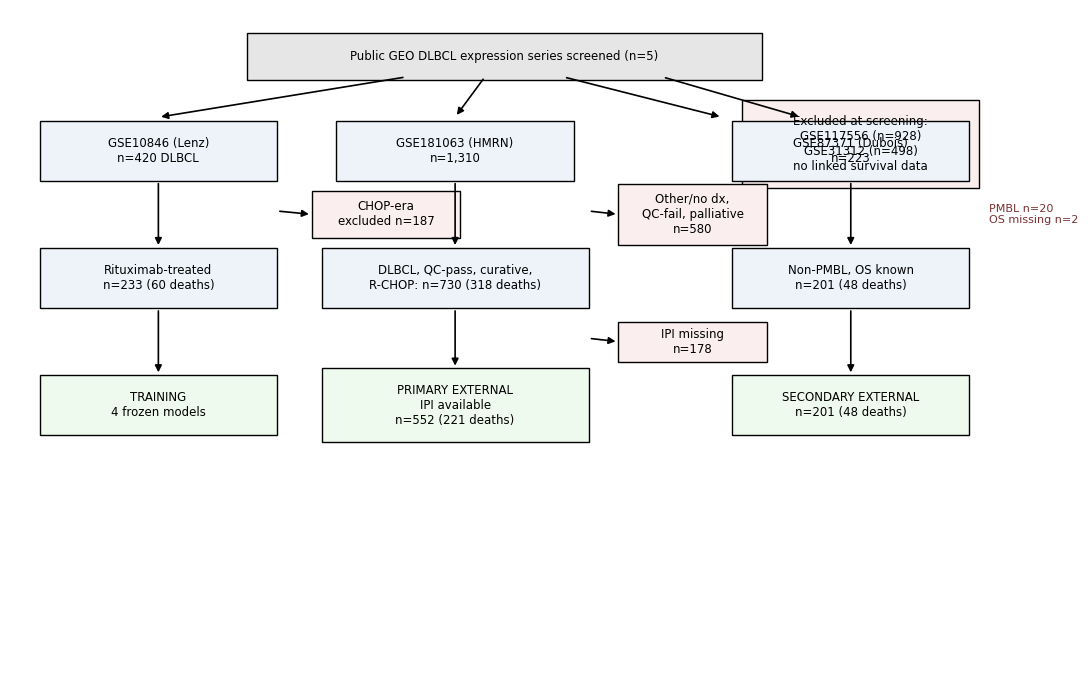

In [21]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 7)); ax.axis("off")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

def box(x, y, text, w=0.24, h=0.09, fc="#eef3fa"):
    ax.add_patch(plt.Rectangle((x-w/2, y-h/2), w, h, facecolor=fc, edgecolor="black", lw=1))
    ax.text(x, y, text, ha="center", va="center", fontsize=8.5)

def arr(x0, y0, x1, y1):
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="-|>", lw=1.2, color="black"))

# root
box(.5, .93, "Public GEO DLBCL expression series screened (n=5)", w=.52, h=.07, fc="#e6e6e6")

# screened-out (hangs right off root)
box(.86, .80, "Excluded at screening:\nGSE117556 (n=928)\nGSE31312 (n=498)\nno linked survival data", w=.24, h=.13, fc="#faeeee")
arr(.66, .90, .80, .84)

# three cohort columns
X1, X2, X3 = .15, .45, .72
arr(.40, .90, X1, .84); arr(.48, .90, X2, .84); arr(.56, .90, X3, .84)

box(X1, .79, "GSE10846 (Lenz)\nn=420 DLBCL")
box(X1, .60, "Rituximab-treated\nn=233 (60 deaths)")
box(X1, .41, "TRAINING\n4 frozen models", fc="#eefaee")
arr(X1, .745, X1, .645); arr(X1, .555, X1, .455)
box(.15+.23, .695, "CHOP-era\nexcluded n=187", w=.15, h=.07, fc="#faeeee")
arr(X1+.12, .70, .15+.155, .695)

box(X2, .79, "GSE181063 (HMRN)\nn=1,310")
box(X2, .60, "DLBCL, QC-pass, curative,\nR-CHOP: n=730 (318 deaths)", w=.27)
box(X2, .41, "PRIMARY EXTERNAL\nIPI available\nn=552 (221 deaths)", w=.27, h=.11, fc="#eefaee")
arr(X2, .745, X2, .645); arr(X2, .555, X2, .465)
box(X2+.24, .695, "Other/no dx,\nQC-fail, palliative\nn=580", w=.15, h=.09, fc="#faeeee")
arr(X2+.135, .70, X2+.165, .695)
box(X2+.24, .505, "IPI missing\nn=178", w=.15, h=.06, fc="#faeeee")
arr(X2+.135, .51, X2+.165, .505)

box(X3+.13, .79, "GSE87371 (Dubois)\nn=223")
box(X3+.13, .60, "Non-PMBL, OS known\nn=201 (48 deaths)", w=.24)
box(X3+.13, .41, "SECONDARY EXTERNAL\nn=201 (48 deaths)", w=.24, h=.09, fc="#eefaee")
arr(X3+.13, .745, X3+.13, .645); arr(X3+.13, .555, X3+.13, .455)
box(X3+.13, .70, "", w=0, h=0)  # no-op spacer
ax.text(X3+.27, .695, "PMBL n=20\nOS missing n=2", fontsize=8, color="#7a3030", va="center")

plt.tight_layout()
plt.savefig("/kaggle/working/fig1_flow.png", dpi=150, bbox_inches="tight")
plt.show()

In [25]:
import glob, os, sys
hits = glob.glob('/kaggle/input/**/lenz_signatures.py', recursive=True)
print(hits)
sys.path.append(os.path.dirname(hits[0]))
from lenz_signatures import GCB_SYMBOLS, STROMAL1_SYMBOLS, STROMAL2_SYMBOLS, LENZ_ALIASES
print(len(GCB_SYMBOLS), len(STROMAL1_SYMBOLS), len(STROMAL2_SYMBOLS))  # 36 260 61

['/kaggle/input/datasets/lawin2593/lenz-signatures-py/lenz_signatures.py']
36 260 61


In [26]:
# --- paste the three *_SYMBOLS lists and LENZ_ALIASES from lenz_signatures.py here, or: ---
# !wget -q -O lenz_signatures.py https://raw.githubusercontent.com/<you>/<repo>/main/lenz_signatures.py
from lenz_signatures import GCB_SYMBOLS, STROMAL1_SYMBOLS, STROMAL2_SYMBOLS, LENZ_ALIASES

def resolve(genes, index):
    """map 2008 symbols -> whatever symbol exists in this cohort's index"""
    out = []
    for g in genes:
        alt = LENZ_ALIASES.get(g, g)
        for cand in (g, alt):
            if cand is not None and cand in index:
                out.append(cand); break
    return out

def lenz_signature(expr_df, genes, ids):
    """Lenz signature value = mean expression (log2 scale) across signature genes — NOT z-scored."""
    g = resolve(genes, expr_df.index)
    return expr_df.loc[g, ids].mean(axis=0), len(g)

def lenz_score(expr_df, ids, standardize=False):
    gcb, n1 = lenz_signature(expr_df, GCB_SYMBOLS, ids)
    s1,  n2 = lenz_signature(expr_df, STROMAL1_SYMBOLS, ids)
    s2,  n3 = lenz_signature(expr_df, STROMAL2_SYMBOLS, ids)
    if standardize:   # cross-platform variant: z-score each signature average within cohort
        gcb, s1, s2 = [(x - x.mean())/x.std() for x in (gcb, s1, s2)]
    score = 8.11 - 0.419*gcb - 1.015*s1 + 0.675*s2     # published coefficients (higher = worse)
    return score, (n1, n2, n3), (gcb, s1, s2)

# ---------- REPRODUCTION GATE on GSE10846 R-CHOP (Lenz's own validation cohort) ----------
# Lenz reported: model quartiles in R-CHOP cohort -> 3-yr OS 89% / 82% / 74% / 48%
sc_tr, ns, (gcb_t, s1_t, s2_t) = lenz_score(expr_tr, tr_ids)
print(f"genes resolved: GCB {ns[0]}/36 | stromal-1 {ns[1]}/260 | stromal-2 {ns[2]}/61")
e_t, t_t = tr["event"].astype(bool), tr["time_yrs"]
print("Training (GSE10846 R-CHOP, n=%d):" % len(tr_ids))
print("  full Lenz score C =", round(concordance_index_censored(e_t, t_t, sc_tr.values)[0],3))
print("  stromal-1 (protective) C =", round(concordance_index_censored(e_t, t_t, -s1_t.values)[0],3))
print("  stromal-2 (adverse)    C =", round(concordance_index_censored(e_t, t_t, s2_t.values)[0],3))
print("  GCB (protective)       C =", round(concordance_index_censored(e_t, t_t, -gcb_t.values)[0],3))

from lifelines import KaplanMeierFitter
q = pd.qcut(sc_tr, 4, labels=["Q1","Q2","Q3","Q4"])
kmf = KaplanMeierFitter(); os3 = {}
for lab in ["Q1","Q2","Q3","Q4"]:
    m = (q == lab).values
    kmf.fit(t_t[m], e_t[m]); os3[lab] = float(kmf.predict(3.0))
print("  3-yr OS by score quartile:", {k: f"{v:.0%}" for k,v in os3.items()}, "| Lenz reported 89/82/74/48%")
gate_pass = (os3["Q1"] > os3["Q4"] + 0.15) and (concordance_index_censored(e_t, t_t, s2_t.values)[0] > 0.5)
print("GATE:", "PASS" if gate_pass else "FAIL")

# ---------- EXTERNAL rows ----------
sc_h, ns_h, _ = lenz_score(expr_val, eval_ids, standardize=True)   # Illumina: standardized variant
sc_h_raw, _, _ = lenz_score(expr_val, eval_ids, standardize=False)
print(f"\nHMRN genes resolved: {ns_h}")
row("Lenz 3-signature model [z-std] GSE181063", eval_ids, sc_h.values)
row("Lenz 3-signature model [raw]   GSE181063", eval_ids, sc_h_raw.values)
sc_87, ns_87, _ = lenz_score(expr3g, ids3)                          # same platform: raw published scale
print(f"GSE87371 genes resolved: {ns_87}")
boot3("Lenz 3-signature model GSE87371", ids3, sc_87.values)

# component rows (stromal only) for comparability with the old flagged rows
_, _, (gcb_h, s1_h, s2_h) = lenz_score(expr_val, eval_ids, standardize=True)
row("Stromal-1 verbatim (protective) GSE181063", eval_ids, -s1_h.values)
row("Stromal-2 verbatim (adverse)    GSE181063", eval_ids, s2_h.values)

genes resolved: GCB 34/36 | stromal-1 256/260 | stromal-2 60/61
Training (GSE10846 R-CHOP, n=233):
  full Lenz score C = 0.692
  stromal-1 (protective) C = 0.595
  stromal-2 (adverse)    C = 0.522
  GCB (protective)       C = 0.663
  3-yr OS by score quartile: {'Q1': '89%', 'Q2': '83%', 'Q3': '67%', 'Q4': '54%'} | Lenz reported 89/82/74/48%
GATE: PASS

HMRN genes resolved: (33, 254, 61)
Lenz 3-signature model [z-std] GSE181063 n= 552  C=0.637 (IPI 0.685)  dC=-0.049 [-0.093, -0.004]
Lenz 3-signature model [raw]   GSE181063 n= 552  C=0.638 (IPI 0.685)  dC=-0.048 [-0.092, -0.003]
GSE87371 genes resolved: (34, 256, 60)
Lenz 3-signature model GSE87371 n=201  C=0.706 (IPI 0.787)  dC=-0.083 [-0.176, +0.004]
Stromal-1 verbatim (protective) GSE181063 n= 552  C=0.601 (IPI 0.685)  dC=-0.085 [-0.133, -0.034]
Stromal-2 verbatim (adverse)    GSE181063 n= 552  C=0.489 (IPI 0.685)  dC=-0.198 [-0.253, -0.145]


In [27]:
# Lenz claim test: does the model add to IPI (their stated use), evaluated externally
from sksurv.linear_model import CoxPHSurvivalAnalysis
# fit combination weights on training (frozen), then apply cold
sc_tr_z = (sc_tr - sc_tr.mean())/sc_tr.std()
Xl_tr = pd.DataFrame({"lenz": sc_tr_z, "ipi": tr["ipi"]}).dropna()
yl = Surv.from_arrays(tr.loc[Xl_tr.index,"event"].astype(bool), tr.loc[Xl_tr.index,"time_yrs"])
m_lenz_ipi = CoxPHSurvivalAnalysis().fit(Xl_tr.values, yl)
print("Lenz+IPI coefs:", dict(zip(Xl_tr.columns, m_lenz_ipi.coef_.round(3))))

sc_h_z = (sc_h - sc_h.mean())/sc_h.std()
Xl_h = pd.DataFrame({"lenz": sc_h_z, "ipi": ev["ipi_given"]}).dropna()
row("Lenz + IPI  GSE181063", Xl_h.index, m_lenz_ipi.predict(Xl_h.values))

sc_87_z = (sc_87 - sc_87.mean())/sc_87.std()
Xl_87 = pd.DataFrame({"lenz": sc_87_z, "ipi": df3.loc[ids3,"ipi_given"]}).dropna()
boot3("Lenz + IPI  GSE87371", Xl_87.index, m_lenz_ipi.predict(Xl_87.values))

Lenz+IPI coefs: {'lenz': np.float64(0.64), 'ipi': np.float64(0.403)}
Lenz + IPI  GSE181063                  n= 552  C=0.713 (IPI 0.685)  dC=+0.028 [-0.002, +0.056]
Lenz + IPI  GSE87371           n=201  C=0.805 (IPI 0.787)  dC=+0.017 [-0.037, +0.067]


In [28]:
expr3g.to_parquet("/kaggle/working/gse87371_expr_genes.parquet")
df3.to_csv("/kaggle/working/gse87371_clin.csv")
clin3.to_csv("/kaggle/working/gse87371_clin_raw.csv")